<link rel="stylesheet" href="notebooks/styles.css">

<div class="title-wrap">
  <h1 class="title-main" style="font-weight: bold; font-size: 2.65rem; margin-bottom: 0.5rem;">
  Spatial Data Science Approaches to Wildfire Severity Modeling
</h1>
<h2 class="title-sub" style="font-style: italic; font-size: 1.8rem; margin-top: 0rem; margin-bottom: 0.2rem;">
  A GIS‑Driven, Tree‑Based Machine Learning Analysis of California Wildfires
</h2>
</div>

# Module 4: *Variable Selection*
##### Version Number: 4.0
---
### Contents  
> 1. *Water Demand*
> 2. *Water Supply*
> 3. *Water Supply Indexes*
> 4. *Fire Danger Indicators*
> 5. *Social Variables*
> 6. *Temporal and Geographic Varaibles*
> 7. *Export File*
---
### Notes
- This module visualizes key variables to assess their relationships with wildfire severity categories. Based on the `Categorical` target, we explore how different weather features interact and correlate with fire risk.
---
### Inputs
- `engineered_samples.csv` engineered and cleaned samples data with weather, fire, and grid data.
---
### Outputs 
- `X`,`y`,`details` - Split training data filtered from 2018 to 2024
- `pal_x`, `pal_y`, `pal_details` - Split training data from 2025 for case study
---
### User Defined Dependencies

In [1]:
import os
import sys

# Allow import of custom modules from the parent directory
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_utils import *
from src.model_utils import *
from src.plot_utils import *

---
### Third Party Dependencies

In [2]:
# Core data tools
import pandas as pd
import numpy as np
from datetime import datetime
import json

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

# Set consistent plotting style
sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

---

In [3]:
def plot_all(df, target1, title):
    grid_kde(df)

### Loading Data

In [4]:
samples = pd.read_csv('../data/processed/engineered_samples.csv')

---

## Split dataset temporarily for variable analysis

In [5]:
# Columns to drop for feature interaction analysis
text_columns = ['Sample_ID', 'Date', 'grid_id',
       'geometry','area_in_cali','maximum_x', 'minimum_y',
       'maximum_y', 'minimum_x','centroid_northing','centroid_easting','Target_Ignition',
               'Year']

coded_columns = ['dominant_province_description','Season']

numerical_data = samples.drop(columns=text_columns + coded_columns)
detail_data = samples[text_columns]

target_ignition = samples['Target_Ignition']

## Scale numerical columns for easier side by side comparisons

In [6]:
scaler = MinMaxScaler()

# Scale main dataset
X_scaled = scaler.fit_transform(numerical_data)
X = pd.DataFrame(X_scaled, columns=numerical_data.columns, index=numerical_data.index)

X = pd.concat([X,samples[coded_columns]],axis=1)

## DIrect Water Demand Indicators

In [7]:
water_demand = [
    "Actual Evapotranspiration",
    "Solar Radiation",
    "Daily Minimum Air Temperature",
    "Daily Maximum Air Temperature",
    "Vapor Pressure Deficit",
    "Wind Speed",
]

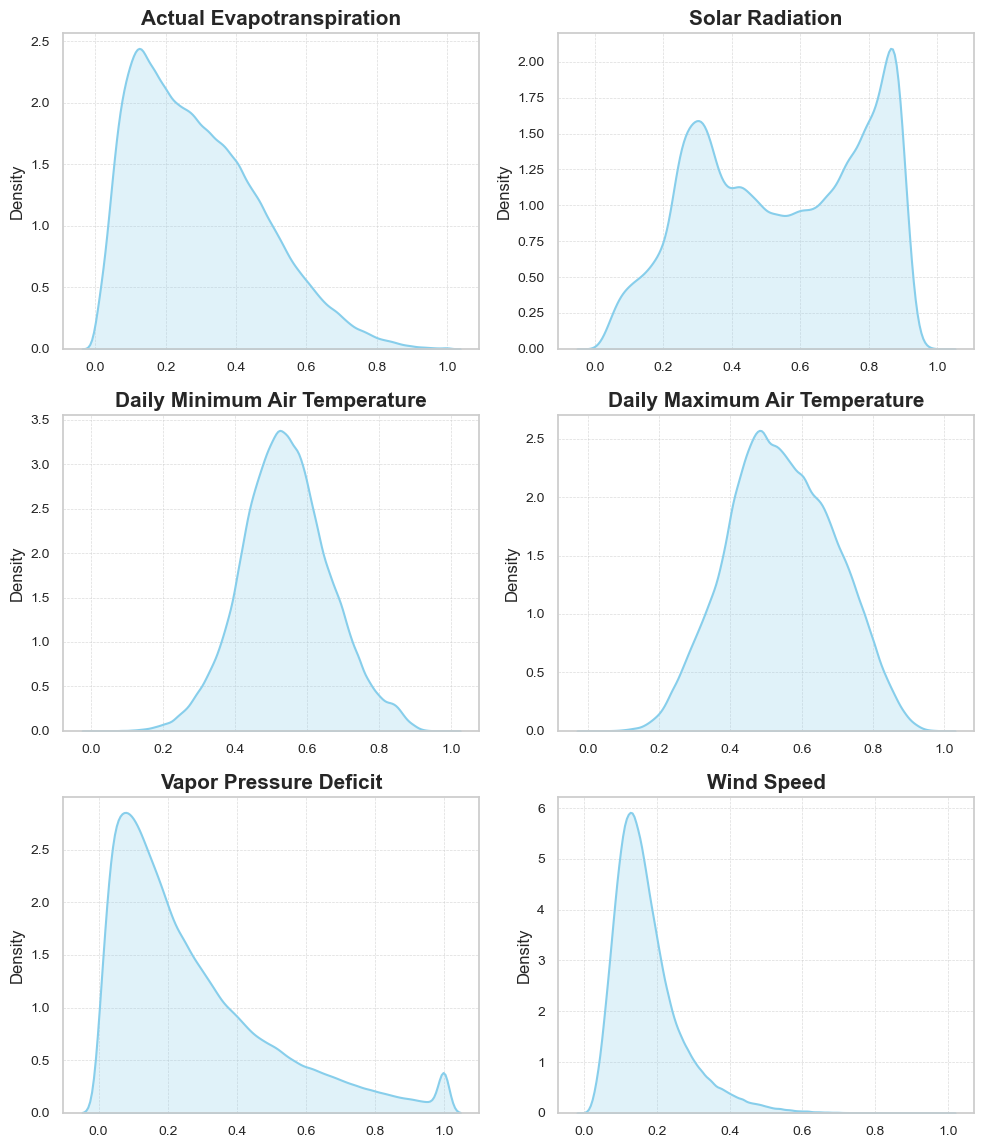

In [8]:
plot_all(X[water_demand], target_ignition,'Water Demand')

---

## Water Supply Indicators

In [9]:
water_supply = [
    "log_Precipitation",
    "Maximum Relative Humidity",
    "Minimum Relative Humidity",
    "Specific Humidity",
    "100-hour Dead Fuel Moisture",
    "1000-hour Dead Fuel Moisture"
]

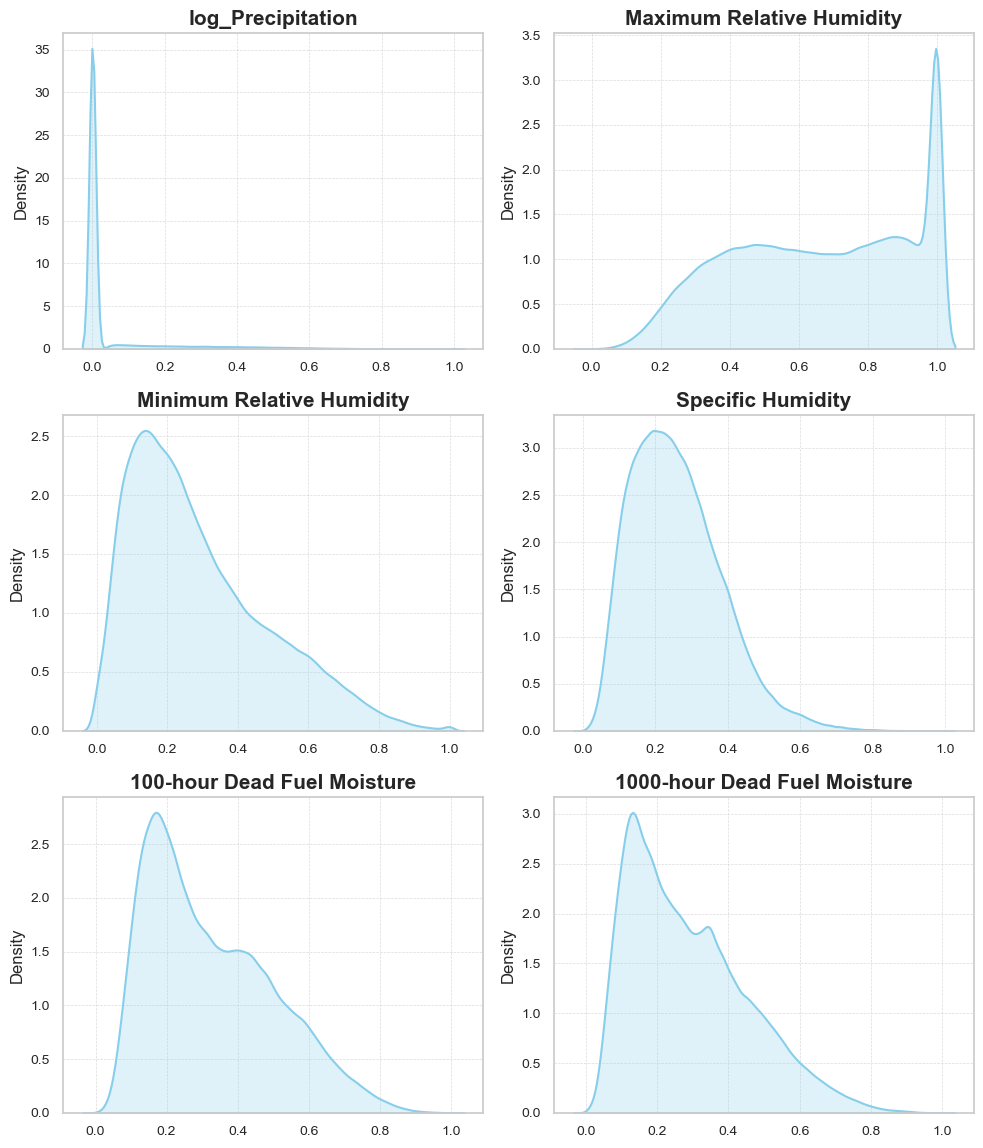

In [10]:
plot_all(X[water_supply], target_ignition,'Water Supply')

---

## Water Supply Indexes

In [11]:
water_supply_indexes = ["SPI 30-Day",
    "SPI 180-Day",
    "SPEI 30-Day",
    "SPEI 90-Day",
    "SPEI 180-Day",
    "Palmer Drought Severity Index"
]

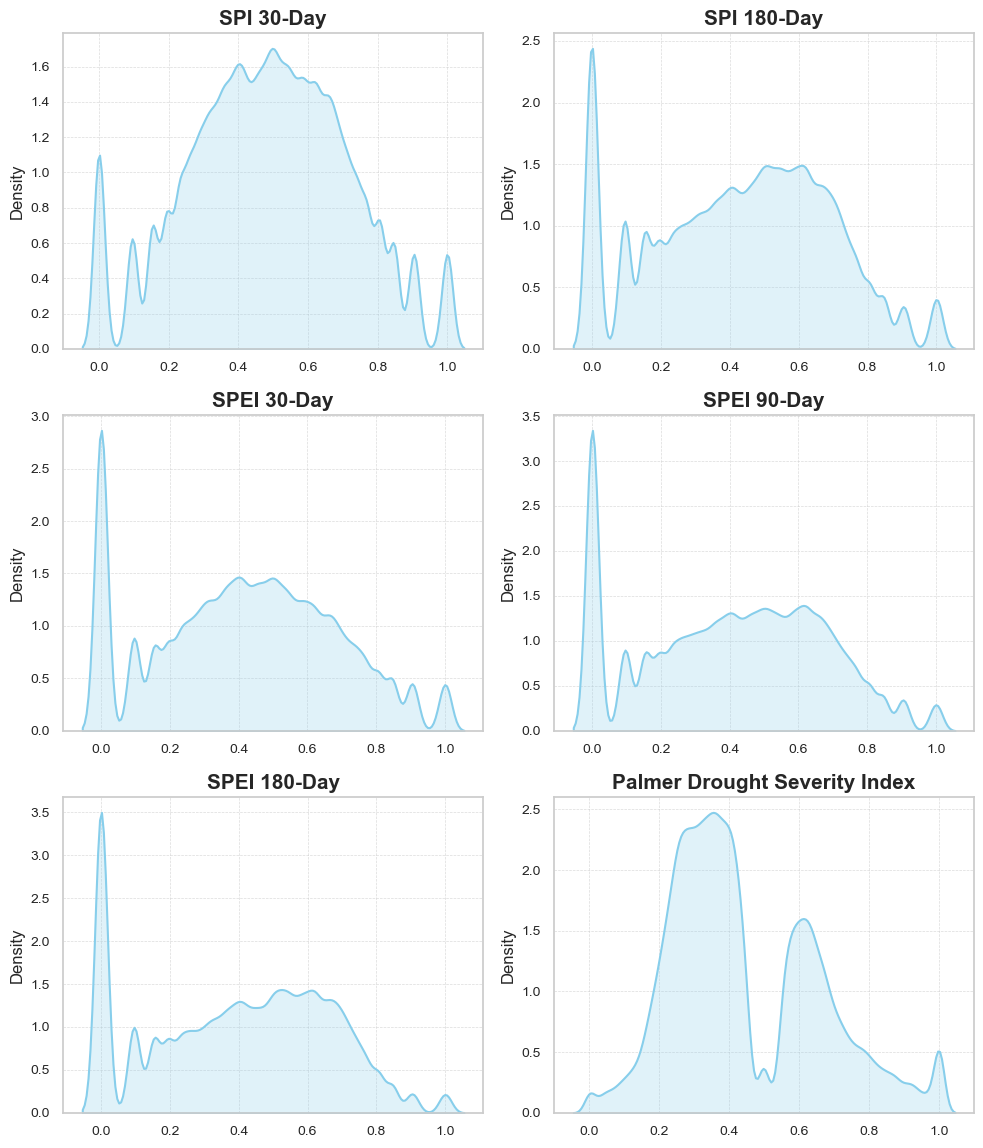

In [12]:
plot_all(X[water_supply_indexes], target_ignition,'Water Supply Indexes')

## Fire Danger

In [13]:
fire_danger = [
    "Burning Index",
    "Energy Release Component",
    'Santa_Ana_Score']

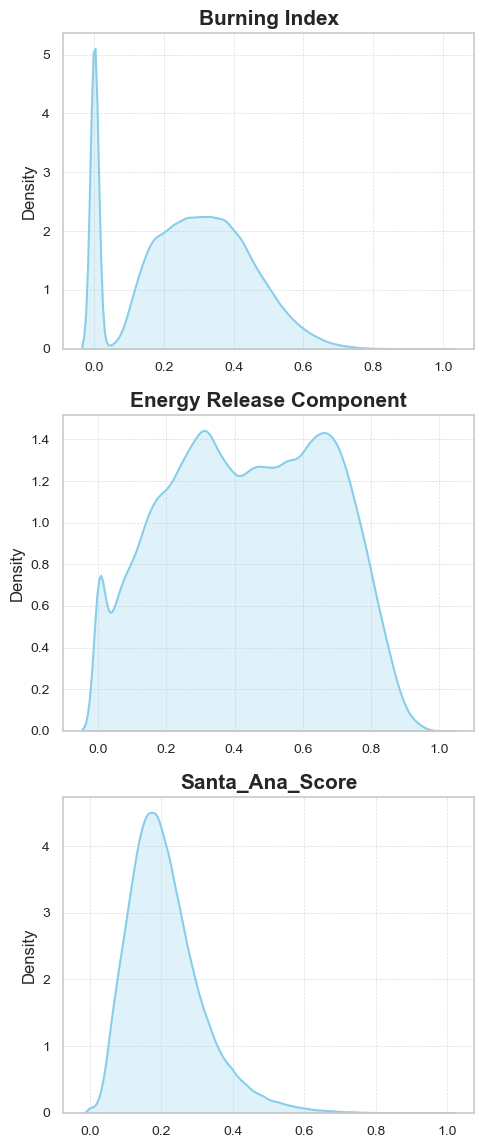

In [14]:
plot_all(X[fire_danger], target_ignition, 'Fire Danger')

## Social Variables

In [15]:
social = ['log_housing_density', 'log_population_density', 'median_income']

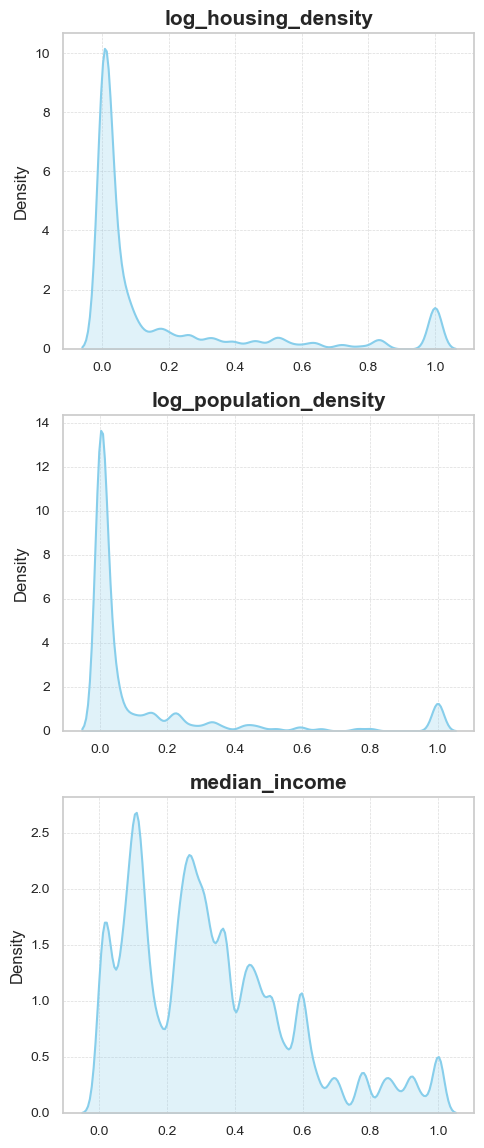

In [16]:
plot_all(X[social], target_ignition, 'Social')

## Infrastructure

In [17]:
infrastructure = ['power_line_density','road_density']

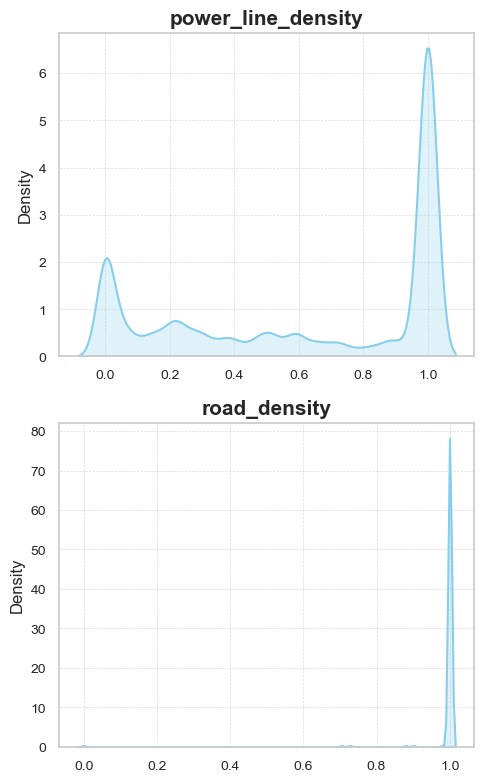

In [18]:
plot_all(X[infrastructure], target_ignition, 'Infrastructure')

## Elevation

In [19]:
elevation = ['elevation_mean', 'slope_mean',
       'northness_mean', 'eastness_mean']

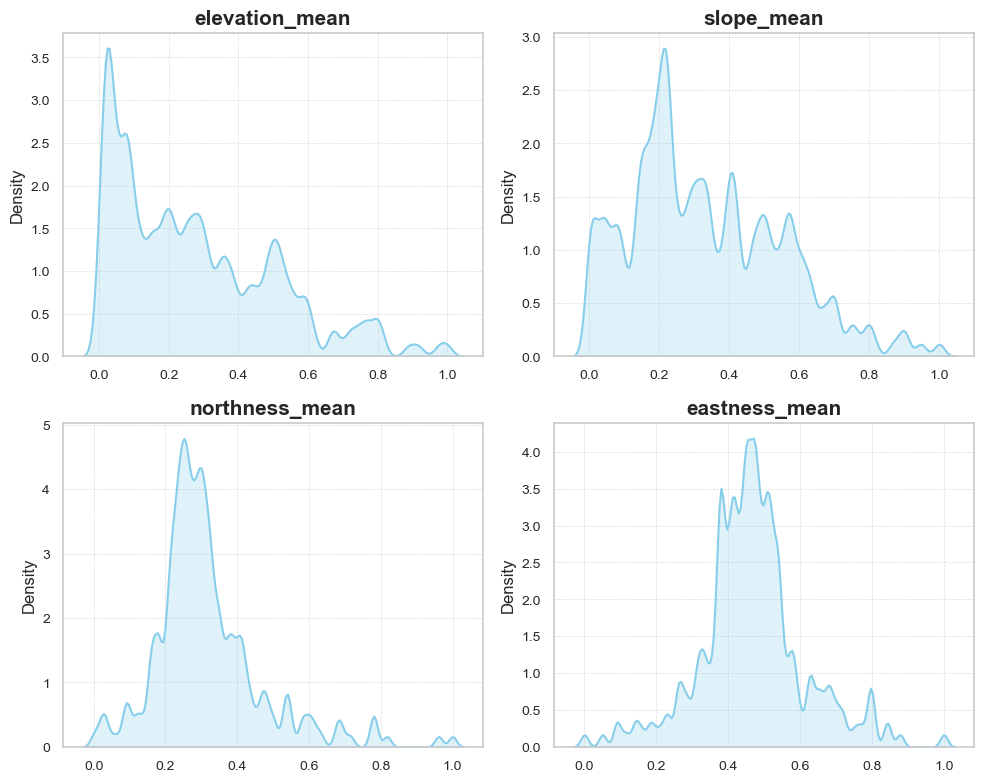

In [20]:
plot_all(X[elevation], target_ignition, 'Elevation')

## WUI

In [21]:
WUI = ['influence_zone', 'interface_zone', 'intermix_zone']

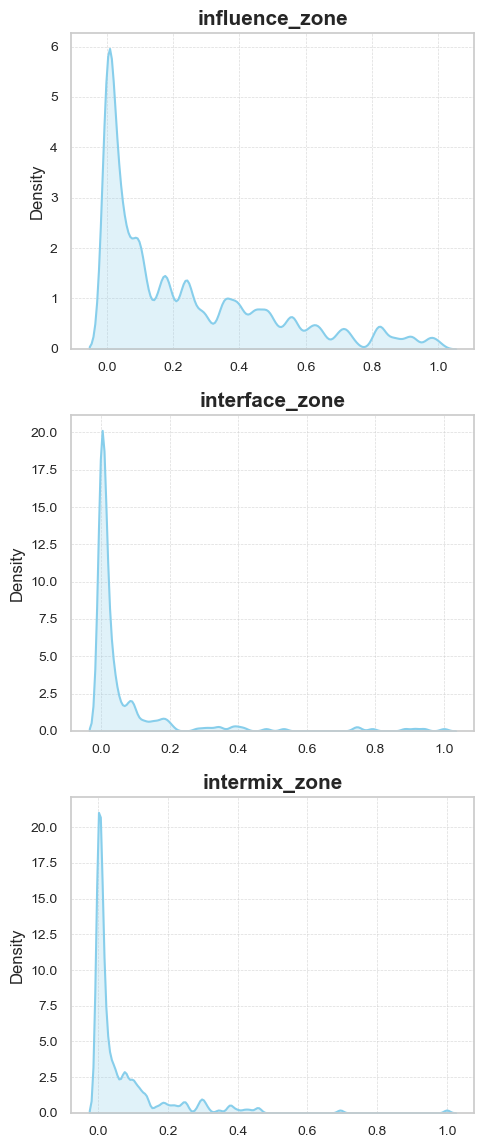

In [22]:
plot_all(X[WUI], target_ignition, 'WUI')

## Land Cover

In [23]:
land_cover = ['forest_percent','developed_percent', 'other_percent', 'shrub_grass_percent',
       'wetlands_percent']

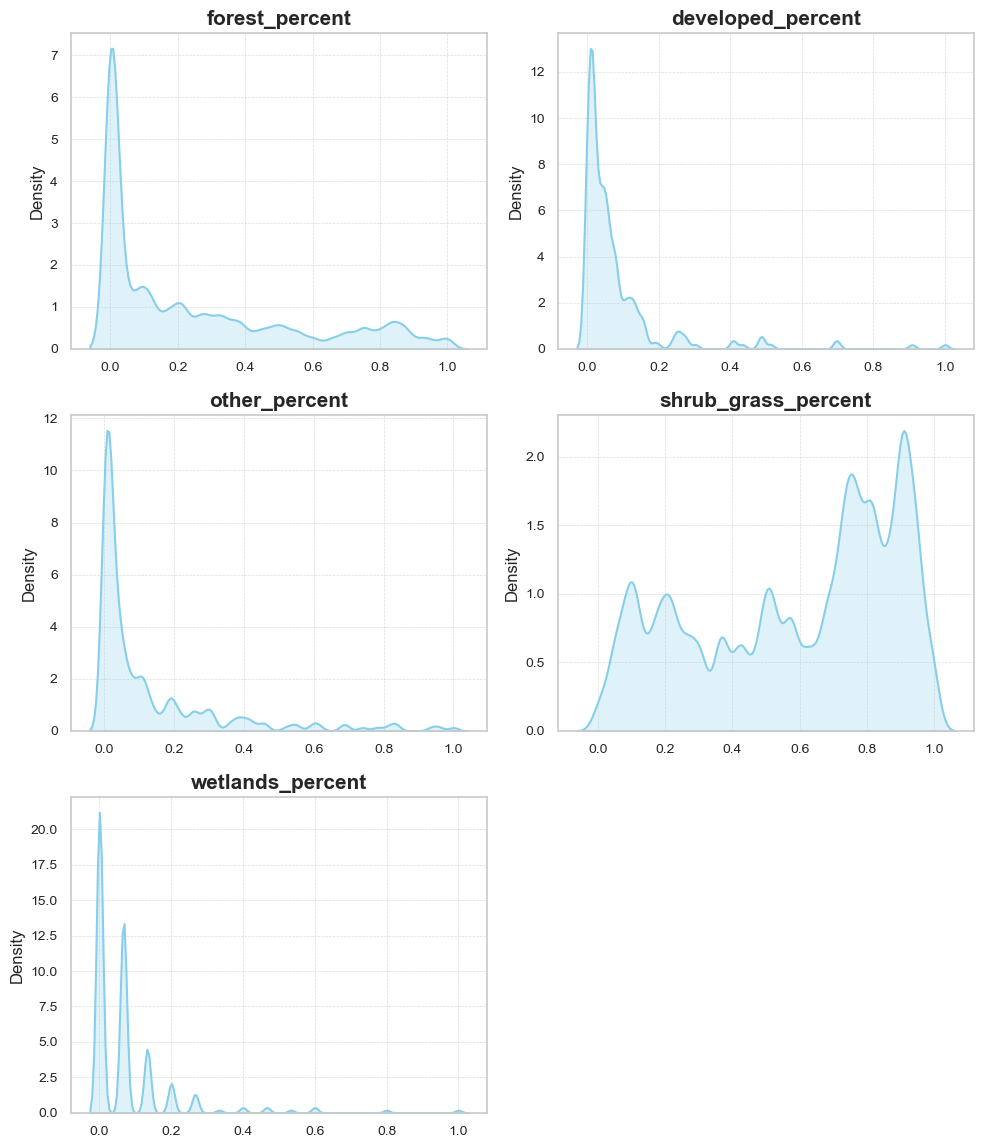

In [24]:
plot_all(X[land_cover], target_ignition, 'Land Cover')

---

In [25]:
interactions = [
 'northness_mean_x_Daily Maximum Air Temperature',
 'road_density_x_forest_percent',
 'power_line_density_x_log_housing_density']

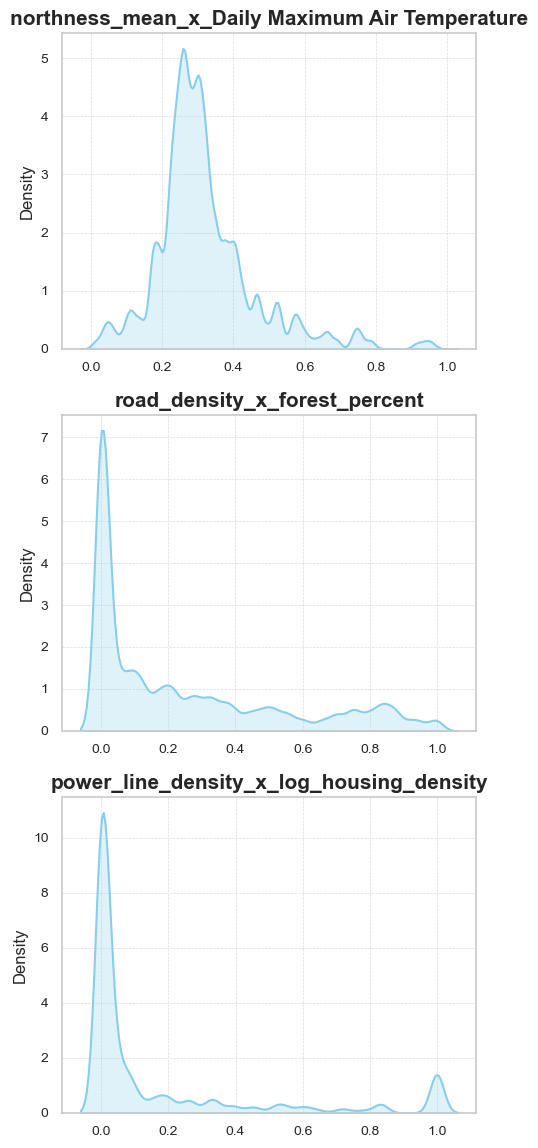

In [26]:
plot_all(X[interactions], target_ignition, 'Interactions')

## Spatial Features

In [27]:
spatial = ['dist_to_fires_same_day','avg_dist_to_fires_same_day',
           'days_since_last_fire']

samples[spatial] = np.sqrt(samples[spatial])

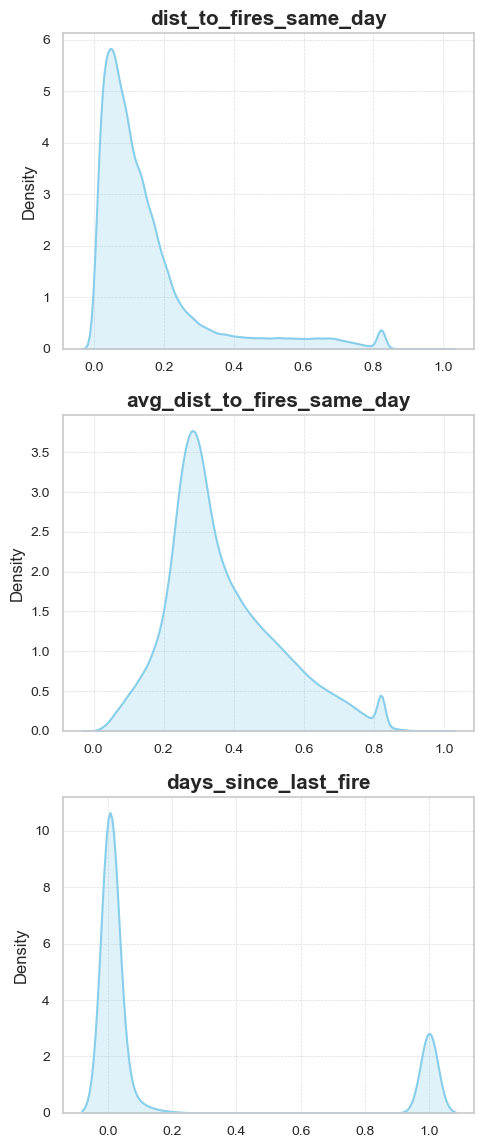

In [28]:
plot_all(X[spatial], target_ignition, 'Spatial')

## Other Features

In [29]:
others = [
    "NDVI_mean_difference",
    "NDVI_mean_difference_has_value",
]

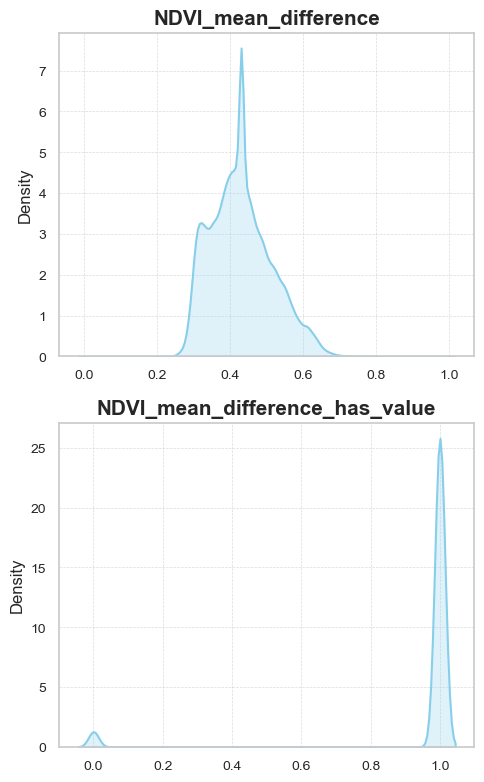

In [30]:
plot_all(X[others], target_ignition, 'Wind Slope Interactions')

In [31]:
coded_ecoregion = [
    # Province
    "dominant_province_description_American Semi-Desert and Desert",
    "dominant_province_description_California Coastal Chaparral Forest and Shrub",
    "dominant_province_description_California Coastal Range Open Woodland-Shrub-Coniferous Forest-Meadow",
    "dominant_province_description_California Coastal Steppe-Mixed Forest-Redwood Forest",
    "dominant_province_description_California Dry Steppe",
    "dominant_province_description_Intermountain Semi-Desert",
    "dominant_province_description_Intermountain Semi-Desert and Desert",
    "dominant_province_description_Sierran Steppe-Mixed Forest-Coniferous Forest-Alpine Meadow",
]

In [32]:
coded_seasons =[
    'Season_Spring',
    'Season_Summer',
    'Season_Fall',
    'Season_Winter'
]

In [33]:
# 3-day lagged features
lag_3_day = [
    "Daily Maximum Air Temperature 3 Day Mean",
    "Vapor Pressure Deficit 3 Day Mean",
    "Wind Speed 3 Day Median",
    "log_Precipitation 3 Day Sum",
    "100-hour Dead Fuel Moisture 3 Day Median"
]

In [34]:
feature_sets =  {
    "Water Demand": water_demand, 
    "Water Supply": water_supply, 
    "Water Supply Indexes": water_supply_indexes, 
    "Fire Danger": fire_danger,
    "Social": social, 
    "Infrastructure": infrastructure,
    "Elevation": elevation, 
    "WUI" : WUI, 
    "Land Cover": land_cover, 
    "Interactions": interactions, 
    "Others": others,
    "Coded Ecoregions": coded_ecoregion,
    "Coded Seasons": coded_seasons,
    'Spatial': spatial,
    "Lag 3 Day Features": lag_3_day,
}

In [35]:
variable_selection_output = pd.concat([X, detail_data], axis=1)

## Export File

In [36]:
with open('../data/processed/feature_sets.json', 'w') as f:
    json.dump(feature_sets, f, indent=4)


print("All datasets saved successfully to ../data/processed/")

All datasets saved successfully to ../data/processed/
